In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../data/Superstore.csv')

#print("\nMissing Values in Data:")
#print(data.isnull().sum())

#print("\nDuplicate Rows in Data:")
#print(data.duplicated().sum())

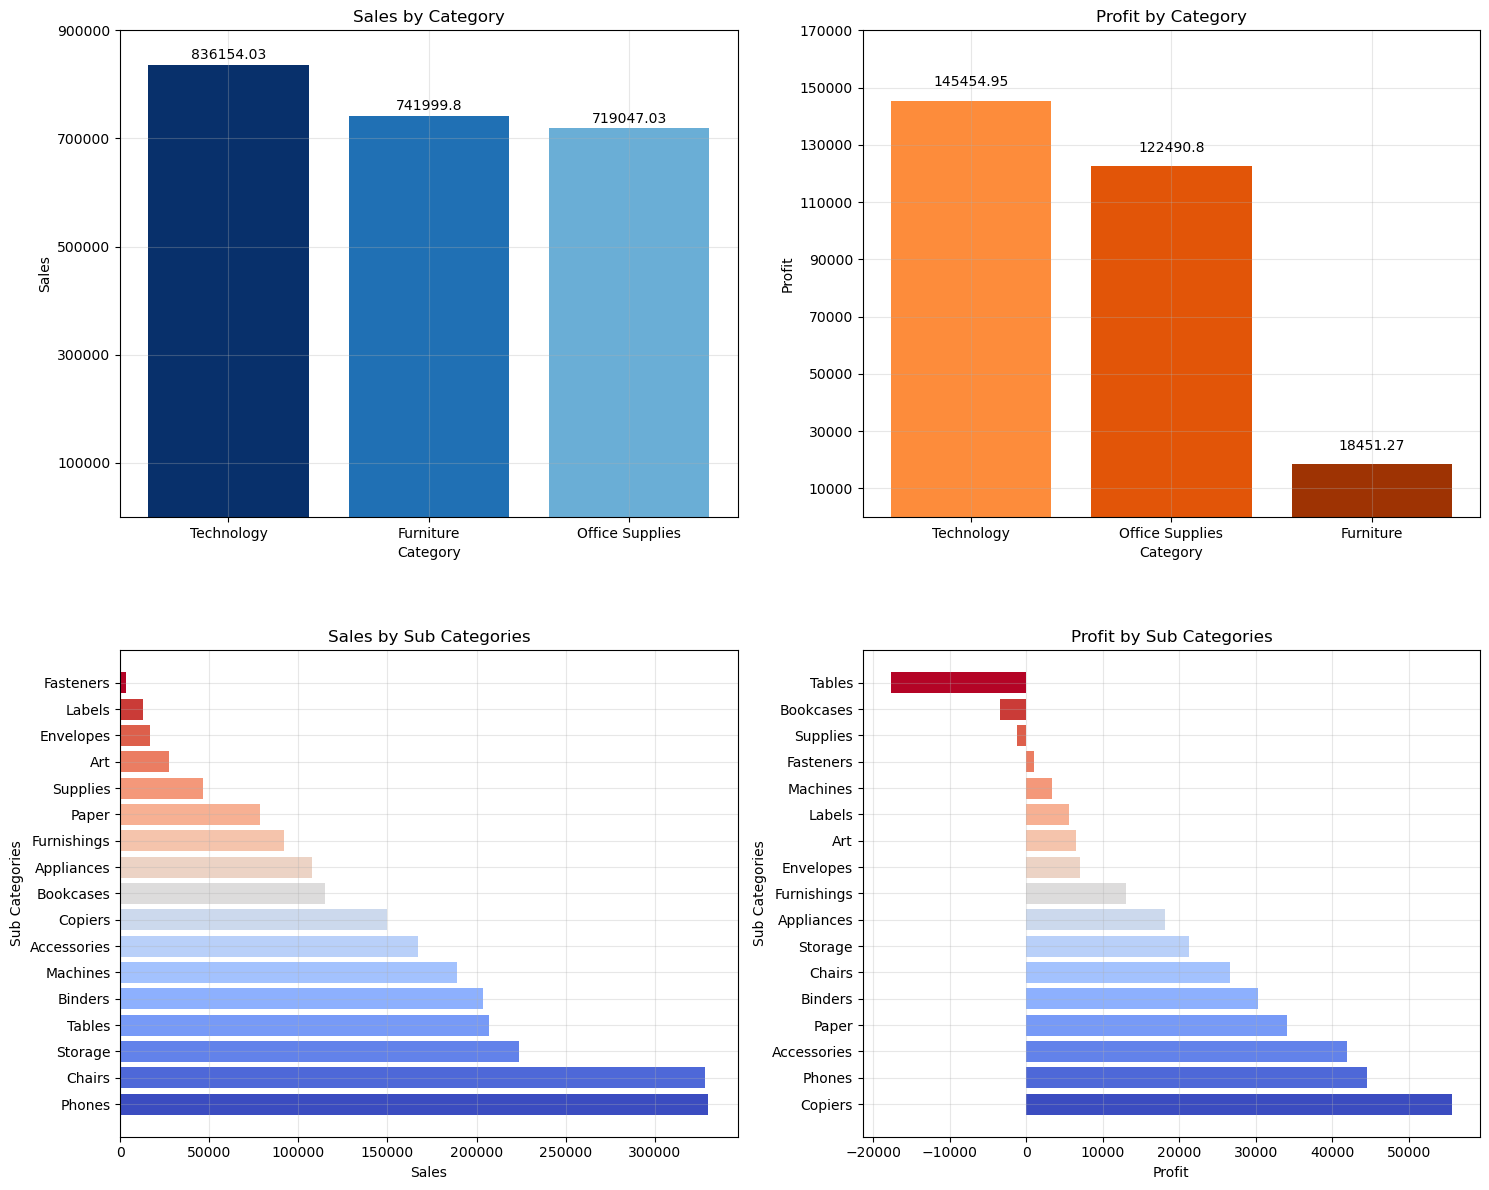


1. Sales by Category

Observation:
- Technology leads in sales.
- Office Supplies records the lowest sales.

Insight:
- Technology is the company's strongest revenue driver.


2. Profit by Category

Observation:
- Technology earns the highest profit.
- Furniture has weaker profit performance.

Insight:
- Higher sales do not always result in higher profit.


3. Sales by Sub Categories

Observation:
- Sales are concentrated in a few sub-categories.
- Several sub-categories contribute minimally.

Insight:
- Revenue depends heavily on a limited product range.


4. Profit by Sub Categories

Observation:
- Profit varies significantly across sub-categories.
- Some products sell well but earn less profit.

Insight:
- Profitability should drive product decisions.



In [3]:
# Analysis 1

# Sales by Category

sales_data = data.groupby("Category")['Sales'].sum().sort_values(ascending=False)
profit_data = data.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sales_subcat_data = data.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
profit_subcat_data = data.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

colors1 = plt.cm.Blues(np.linspace(1, 0.5, len(sales_data)))
colors2 = plt.cm.Oranges(np.linspace(0.5, 0.9, len(profit_data)))
colors3 = plt.cm.coolwarm(np.linspace(0, 1, len(sales_subcat_data)))
colors4 = plt.cm.coolwarm(np.linspace(0, 1, len(profit_subcat_data)))

# Modern Matplotlib - oop
fig, axes = plt.subplots(2,2, figsize=(15,12))

axes[0][0].bar(sales_data.index,sales_data,color=colors1)
axes[0][0].set_title('Sales by Category')
axes[0][0].set_xlabel('Category')
axes[0][0].set_ylabel('Sales')
axes[0][0].set_yticks(range(100000, int(max(sales_data)) + 100000, 200000))
axes[0][0].grid(alpha=0.3)

for i in range(len(sales_data.index)):
    axes[0][0].text(sales_data.index[i],
                 sales_data.iloc[i]+10000,
                 round(sales_data.iloc[i],2),
            ha='center')

# Profit by Category

axes[0][1].bar(profit_data.index,profit_data,color=colors2)
axes[0][1].set_title("Profit by Category")
axes[0][1].set_xlabel("Category")
axes[0][1].set_ylabel("Profit")
axes[0][1].set_yticks(range(10000, int(max(profit_data)) + 30000, 20000))
axes[0][1].grid(alpha=0.3)

for i in range(len(profit_data)):
    axes[0][1].text(profit_data.index[i],
                 profit_data.iloc[i]+5000,
                 round(profit_data.iloc[i],2),
                 ha='center')

# Sales by Sub Categories

axes[1][0].barh(sales_subcat_data.index,sales_subcat_data,color=colors3)
axes[1][0].set_title('Sales by Sub Categories')
axes[1][0].set_xlabel('Sales')
axes[1][0].set_ylabel('Sub Categories')
axes[1][0].grid(alpha=0.3)

# Profit by Sub Categories

axes[1][1].barh(profit_subcat_data.index,profit_subcat_data,color=colors4)
axes[1][1].set_title('Profit by Sub Categories')
axes[1][1].set_xlabel('Profit')
axes[1][1].set_ylabel('Sub Categories')
axes[1][1].grid(alpha=0.3)

fig.tight_layout(h_pad=5) # space between graphs
#plt.subplots_adjust(hspace=0.5)  # space between graphs

plt.savefig('../images/sales_&_profit_by_category.png', bbox_inches="tight")
plt.show()

print("""
1. Sales by Category

Observation:
- Technology leads in sales.
- Office Supplies records the lowest sales.

Insight:
- Technology is the company's strongest revenue driver.
""")

print("""
2. Profit by Category

Observation:
- Technology earns the highest profit.
- Furniture has weaker profit performance.

Insight:
- Higher sales do not always result in higher profit.
""")
    
print("""
3. Sales by Sub Categories

Observation:
- Sales are concentrated in a few sub-categories.
- Several sub-categories contribute minimally.

Insight:
- Revenue depends heavily on a limited product range.
""")

print("""
4. Profit by Sub Categories

Observation:
- Profit varies significantly across sub-categories.
- Some products sell well but earn less profit.

Insight:
- Profitability should drive product decisions.
""")

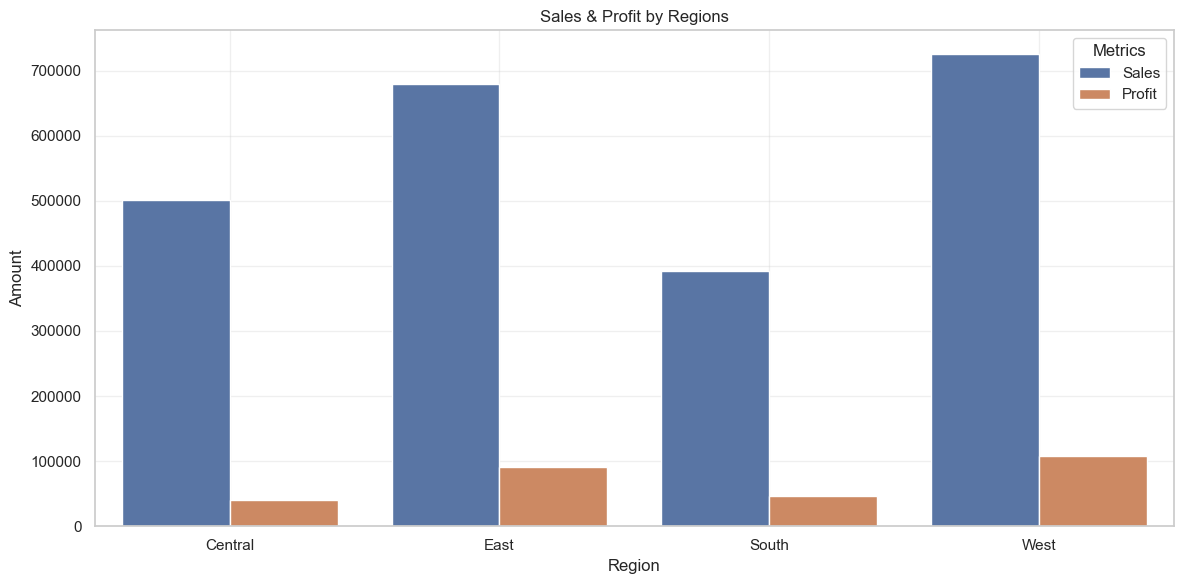


1. Sales & Profit by Region

Observation:
- West performs best in both sales and profit.
- South contributes the least.

Insight:
- Regional performance is uneven across markets.



In [4]:
# Analysis 2
# Sales & Profit by Regions

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

region_data = data.groupby('Region')[['Sales','Profit']].sum().reset_index()

region_data = region_data.melt(
    id_vars='Region',
    value_vars=['Sales','Profit'],
    var_name = 'Metrics',
    value_name = 'Amount'
)

sns.barplot(
    data=region_data,
    x='Region',
    y='Amount',
    hue='Metrics',
)

plt.title("Sales & Profit by Regions")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.savefig('../images/sales_&_profit_by_region.png', bbox_inches="tight")
plt.show()

print("""
1. Sales & Profit by Region

Observation:
- West performs best in both sales and profit.
- South contributes the least.

Insight:
- Regional performance is uneven across markets.
""")

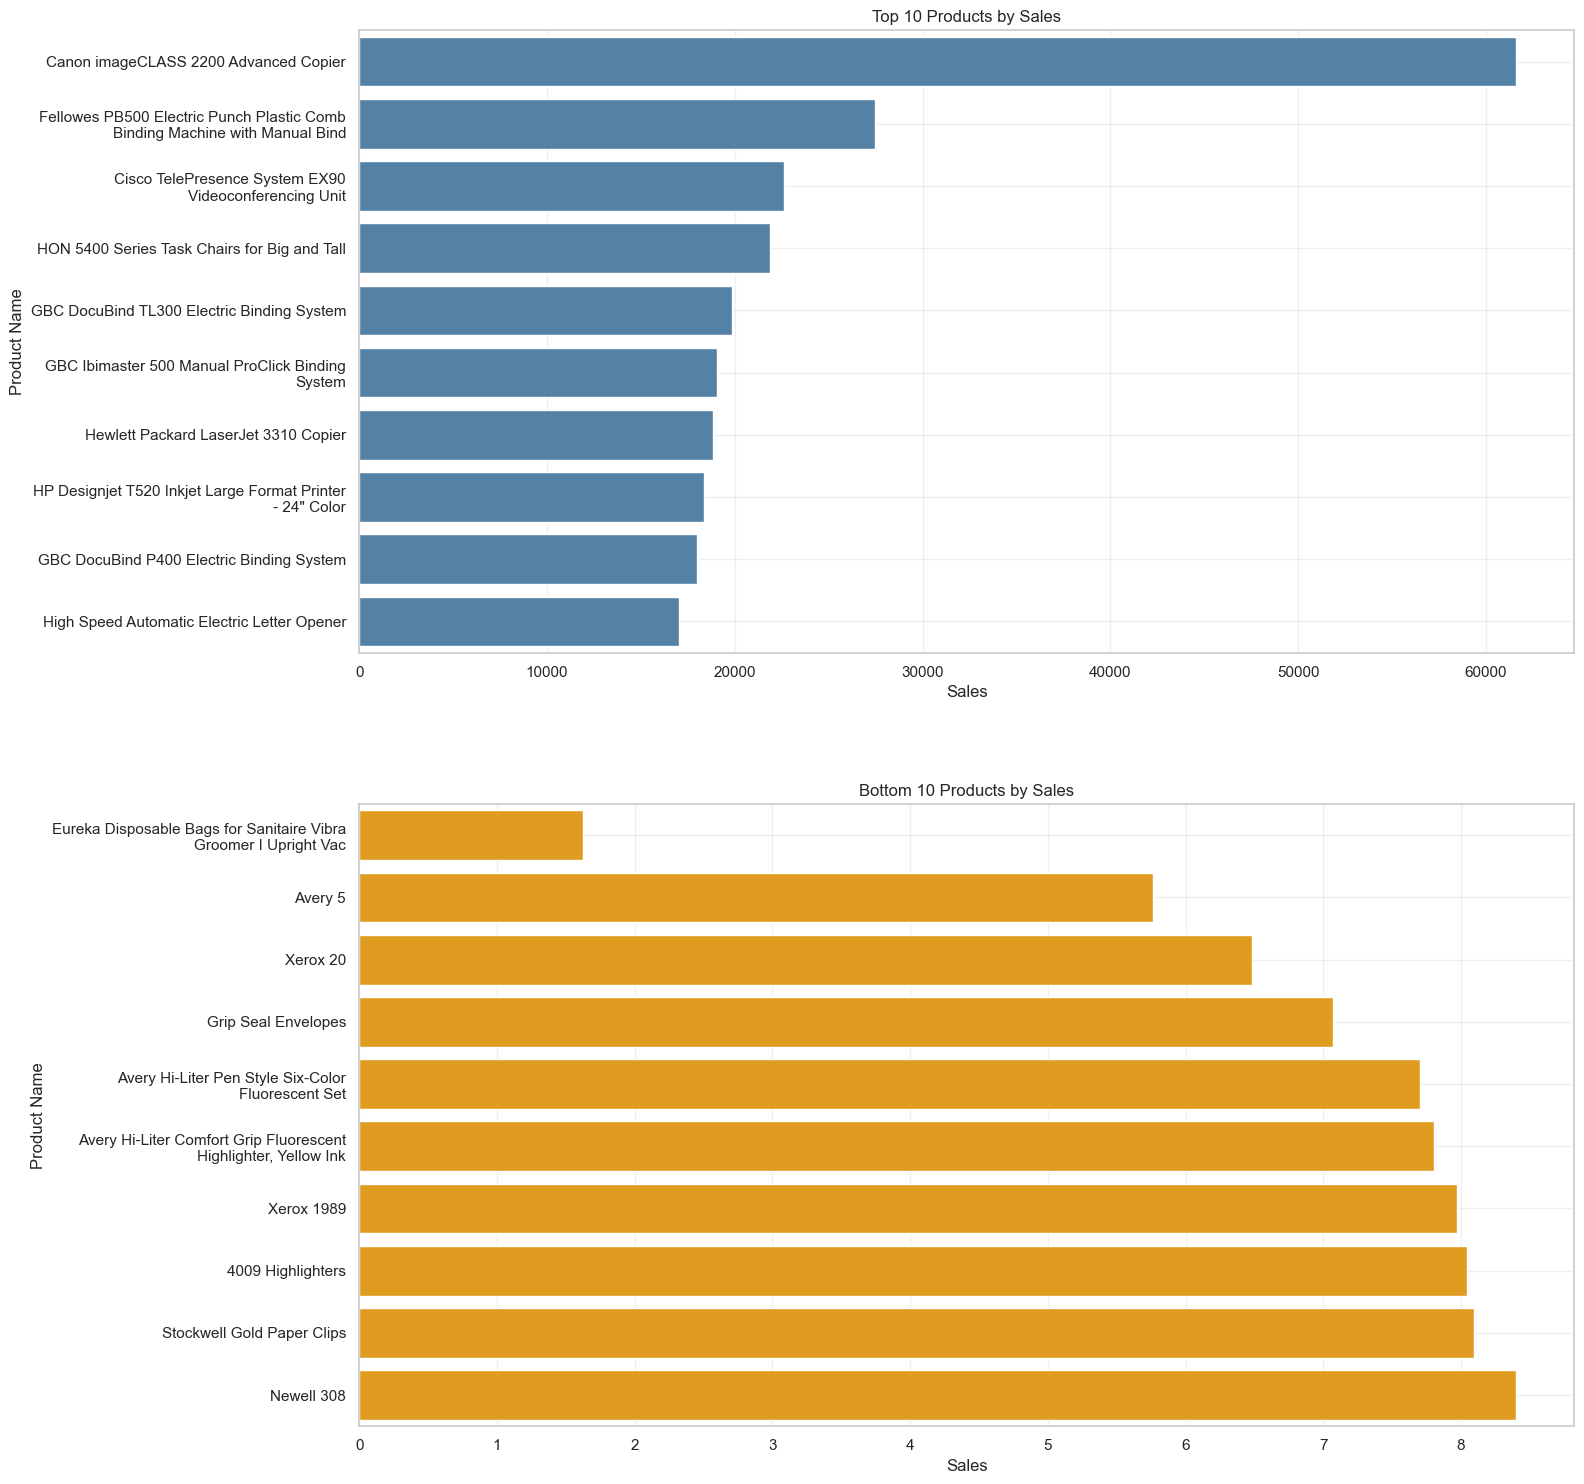


1. Top 10 Revenue-Generating Products

Observation:
- A few products dominate total sales.
- Sales decline sharply after the top products.

Insight:
- High-performing products deserve priority.


2. Lowest Selling Products

Observation:
- These products contribute very little revenue.
- Demand remains consistently low.

Insight:
- Poor-performing products need business review.



In [5]:
# Analysis 3

# Top 10 Products by Sales

from textwrap import fill

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16,15))

top_products = (data.groupby('Product Name')['Sales'].sum()
    .sort_values(ascending=False)
    .head(10).reset_index())

bottom_products = (data.groupby('Product Name')['Sales'].sum()
    .sort_values()
    .head(10).reset_index())

# Wrap product names after 45 characters
top_products['Product Name'] = top_products['Product Name'].apply(lambda x: fill(x, width=45))
bottom_products['Product Name'] = bottom_products['Product Name'].apply(lambda x: fill(x, width=45))

sns.barplot(data=top_products,
            x='Sales',
            y='Product Name',
            ax=axes[0],
            color='steelblue')

axes[0].set_title("Top 10 Products by Sales")
axes[0].grid(alpha=0.3)

# Bottom 10 Products by Sales

sns.barplot(data=bottom_products,
            x='Sales',
            y='Product Name',
            ax=axes[1],
            color='orange')

axes[1].set_title("Bottom 10 Products by Sales")
axes[1].grid(alpha=0.3)

fig.tight_layout(h_pad=5) # space between graphs
plt.savefig('../images/top_&_lowest_10_products_by_sales.png', bbox_inches="tight")

plt.show()

print("""
1. Top 10 Revenue-Generating Products

Observation:
- A few products dominate total sales.
- Sales decline sharply after the top products.

Insight:
- High-performing products deserve priority.
""")

print("""
2. Lowest Selling Products

Observation:
- These products contribute very little revenue.
- Demand remains consistently low.

Insight:
- Poor-performing products need business review.
""")

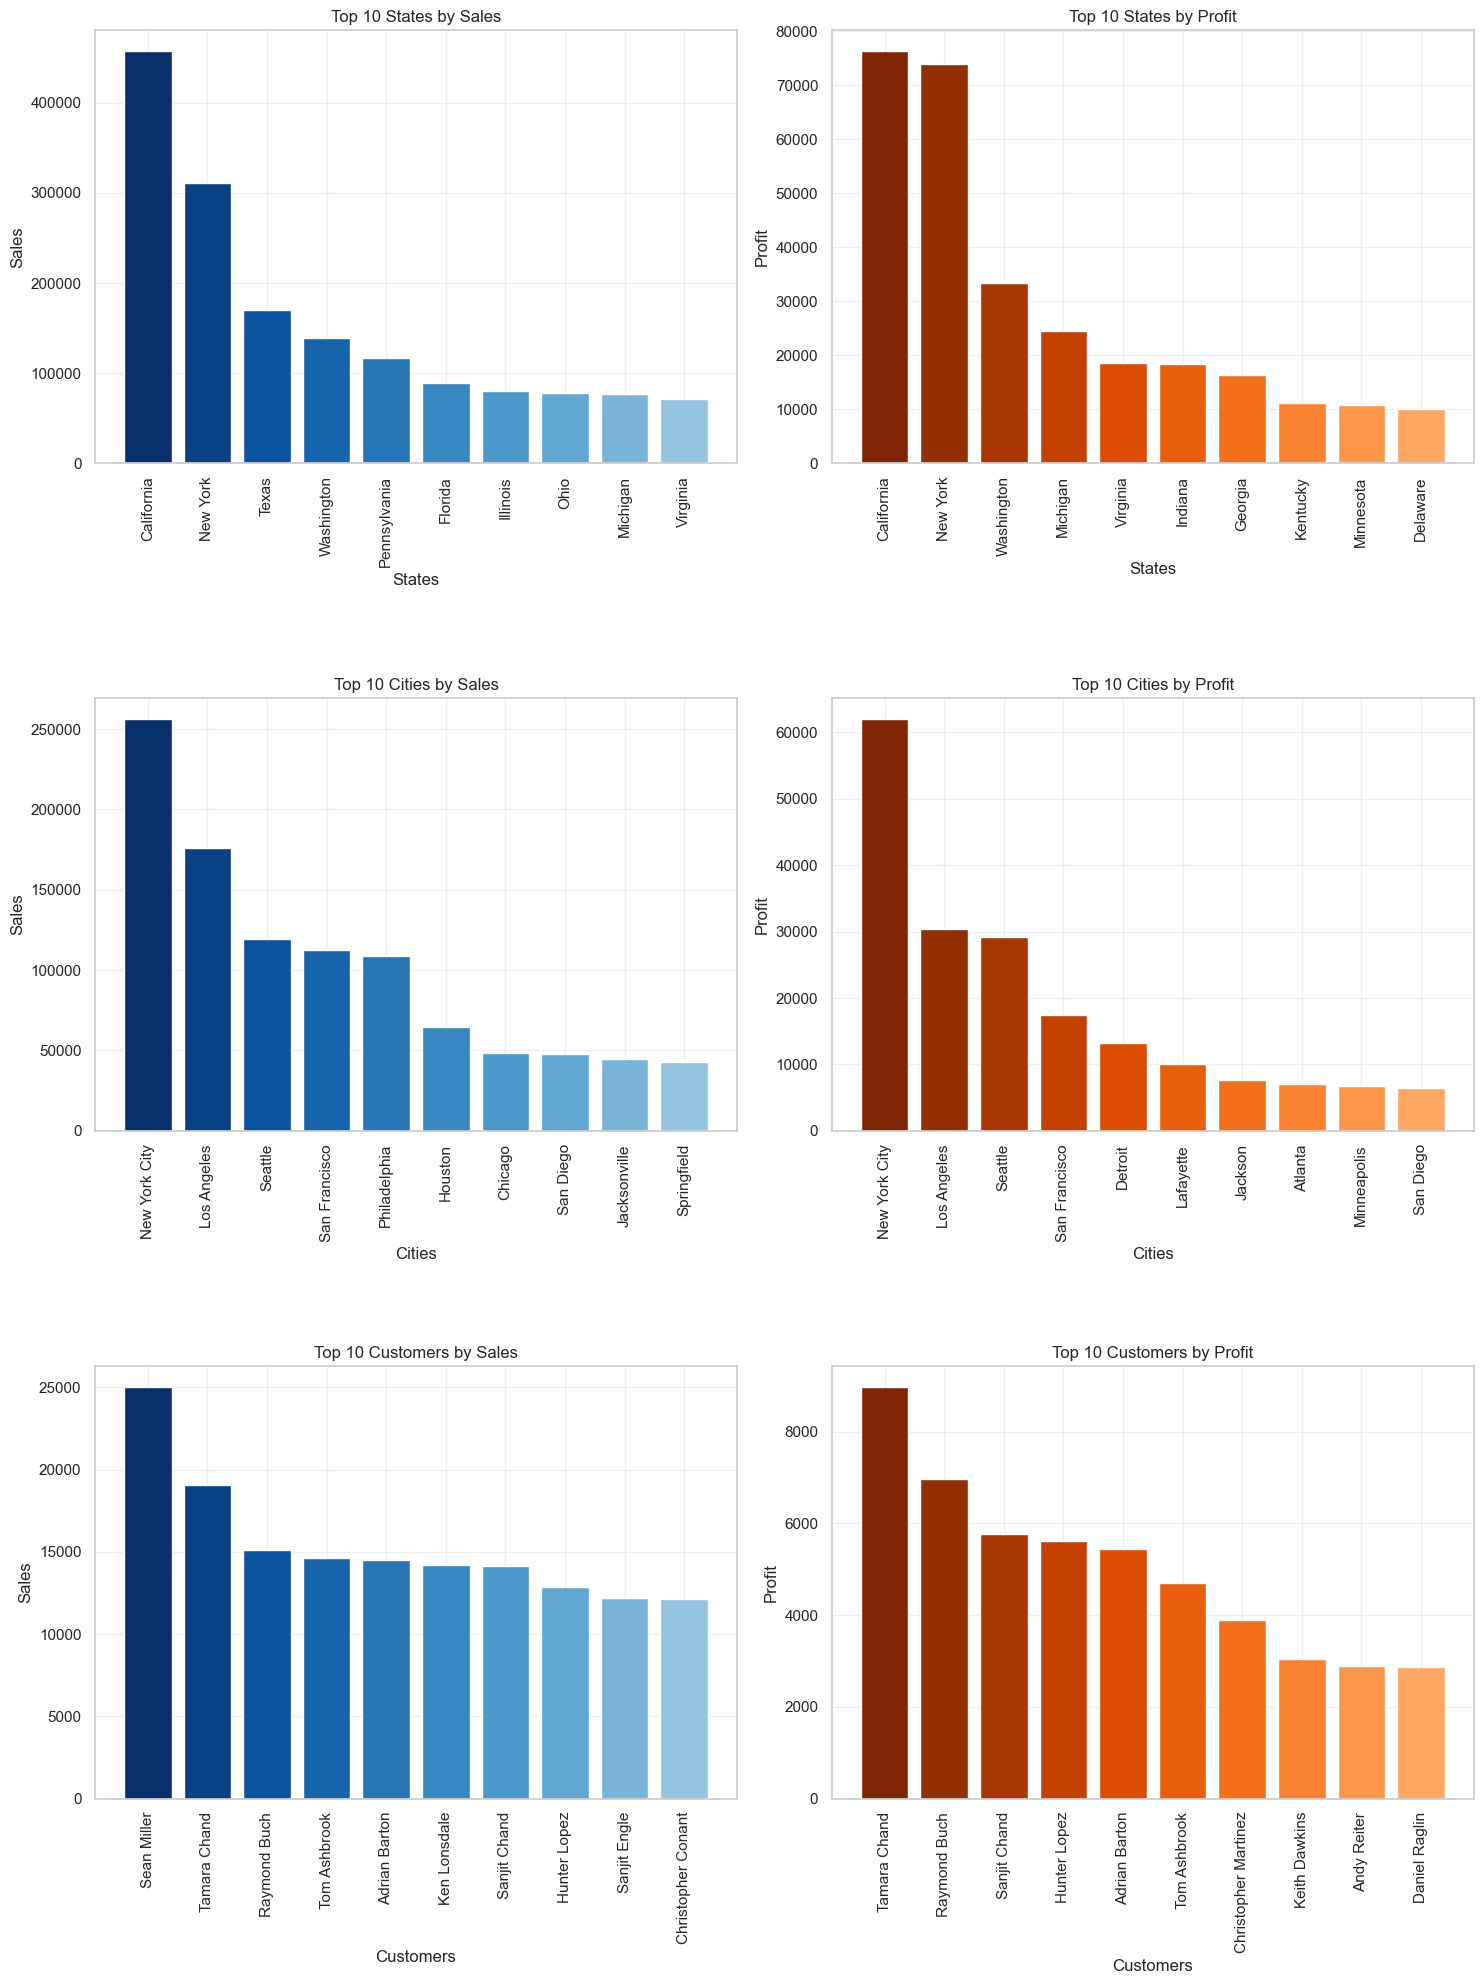


1. Top 10 States by Sales

Observation:
- Sales are concentrated in a few states.
- Several states contribute significantly more revenue.

Insight:
- Geographic demand is concentrated.


2. Top 10 States by Profit

Observation:
- Profit differs across states.
- High-sales states are not always most profitable.

Insight:
- Profitability varies by location.


3. Top 10 Cities by Sales

Observation:
- Major cities account for most sales.
- Revenue is city-centric.

Insight:
- Urban markets drive business growth.


4. Top 10 Cities by Profit

Observation:
- Profit is concentrated in a few cities.
- City profitability differs significantly.

Insight:
- Focus expansion on high-margin cities.


5. Top 10 Customers by Sales

Observation:
- A small group of customers generates high sales.
- Customer spending is uneven.

Insight:
- Retaining key customers is essential.


6. Top 10 Customers by Profit

Observation:
- Customer profit contribution varies.
- High spending doesn't always mean high p

In [6]:
# Analysis 4

state_sale = data.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
state_profit = data.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)
city_sale = data.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
city_profit = data.groupby('City')['Profit'].sum().sort_values(ascending=False).head(10)
customer_sale = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
customer_profit = data.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

colors1 = plt.cm.Blues(np.linspace(1, 0.4, len(state_sale)))
colors2 = plt.cm.Oranges(np.linspace(1, 0.4, len(state_profit)))
colors3 = plt.cm.Blues(np.linspace(1, 0.4, len(city_sale)))
colors4 = plt.cm.Oranges(np.linspace(1, 0.4, len(city_profit)))
colors5 = plt.cm.Blues(np.linspace(1, 0.4, len(customer_sale)))
colors6 = plt.cm.Oranges(np.linspace(1, 0.4, len(customer_profit)))

fig, axes = plt.subplots(3,2, figsize=(15,20))

#Top 10 States by Sales

axes[0][0].bar(state_sale.index,state_sale,color=colors1)
axes[0][0].set_title('Top 10 States by Sales')
axes[0][0].set_xlabel('States')
axes[0][0].set_ylabel('Sales')

axes[0][0].tick_params(axis='x', labelrotation=90) # Rotate x-axis labels
plt.setp(axes[0][0].get_xticklabels(), ha='center') # Set the property on all the objects.

axes[0][0].grid(alpha=0.3)

#Top 10 States by Profit

axes[0][1].bar(state_profit.index,state_profit,color=colors2)
axes[0][1].set_title('Top 10 States by Profit')
axes[0][1].set_xlabel('States')
axes[0][1].set_ylabel('Profit')
axes[0][1].tick_params(axis='x', labelrotation=90)
plt.setp(axes[0][1].get_xticklabels(), ha='center')
axes[0][1].grid(alpha=0.3)

#Top 10 Cities by Sales

axes[1][0].bar(city_sale.index,city_sale,color=colors3)
axes[1][0].set_title('Top 10 Cities by Sales')
axes[1][0].set_xlabel('Cities')
axes[1][0].set_ylabel('Sales')
axes[1][0].tick_params(axis='x', labelrotation=90)
plt.setp(axes[1][0].get_xticklabels(), ha='center')
axes[1][0].grid(alpha=0.3)

#Top 10 Cities by Profit

axes[1][1].bar(city_profit.index,city_profit,color=colors4)
axes[1][1].set_title('Top 10 Cities by Profit')
axes[1][1].set_xlabel('Cities')
axes[1][1].set_ylabel('Profit')
axes[1][1].tick_params(axis='x', labelrotation=90)
plt.setp(axes[1][1].get_xticklabels(), ha='center')
axes[1][1].grid(alpha=0.3)

#Top 10 Customers by Sales

axes[2][0].bar(customer_sale.index,customer_sale,color=colors5)
axes[2][0].set_title('Top 10 Customers by Sales')
axes[2][0].set_xlabel('Customers')
axes[2][0].set_ylabel('Sales')
axes[2][0].tick_params(axis='x', labelrotation=90)
plt.setp(axes[2][0].get_xticklabels(), ha='center')
axes[2][0].grid(alpha=0.3)

#Top 10 Customers by Profit

axes[2][1].bar(customer_profit.index,customer_profit,color=colors6)
axes[2][1].set_title('Top 10 Customers by Profit')
axes[2][1].set_xlabel('Customers')
axes[2][1].set_ylabel('Profit')
axes[2][1].tick_params(axis='x', labelrotation=90)
plt.setp(axes[2][1].get_xticklabels(), ha='center')
axes[2][1].grid(alpha=0.3)

plt.savefig('../images/top_10_sales_profit_by_state_city_customer.png', bbox_inches="tight")
fig.tight_layout(h_pad=5)
plt.show()

print("""
1. Top 10 States by Sales

Observation:
- Sales are concentrated in a few states.
- Several states contribute significantly more revenue.

Insight:
- Geographic demand is concentrated.
""")

print("""
2. Top 10 States by Profit

Observation:
- Profit differs across states.
- High-sales states are not always most profitable.

Insight:
- Profitability varies by location.
""")

print("""
3. Top 10 Cities by Sales

Observation:
- Major cities account for most sales.
- Revenue is city-centric.

Insight:
- Urban markets drive business growth.
""")

print("""
4. Top 10 Cities by Profit

Observation:
- Profit is concentrated in a few cities.
- City profitability differs significantly.

Insight:
- Focus expansion on high-margin cities.
""")

print("""
5. Top 10 Customers by Sales

Observation:
- A small group of customers generates high sales.
- Customer spending is uneven.

Insight:
- Retaining key customers is essential.
""")

print("""
6. Top 10 Customers by Profit

Observation:
- Customer profit contribution varies.
- High spending doesn't always mean high profit.

Insight:
- Focus on profitable customer segments.
""")

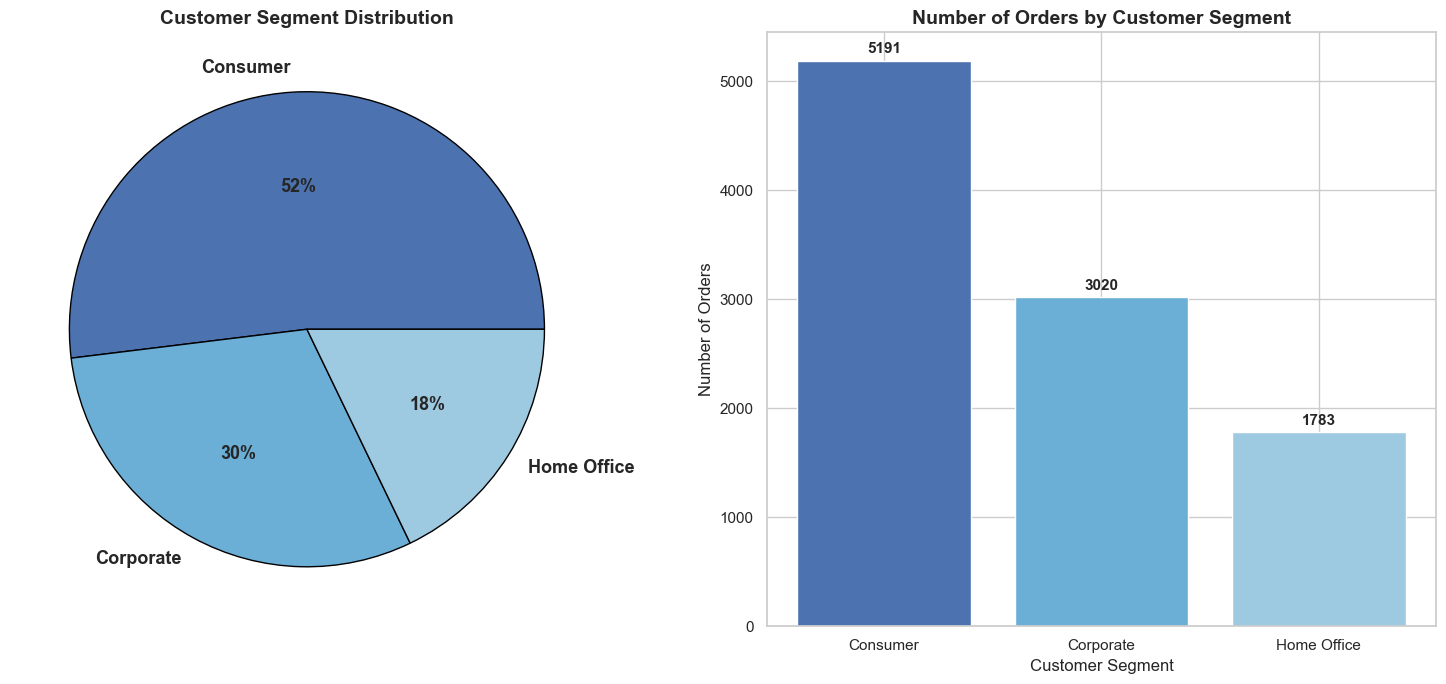


1. Customer Segment Distribution

Observation:
- Consumer is the largest segment.
- Home Office is the smallest.

Insight:
- Consumer segment drives overall business.


2. Order Distribution by Customer Segment

Observation:
- Consumers place the most orders.
- Home Office places the fewest.

Insight:
- Consumer demand dominates order volume.



In [9]:
# Analysis 5
# Count of Segment

segment = data.groupby('Segment')['Order ID'].count()

fig, ax = plt.subplots(1,2, figsize=(15,7))
colors = ['#4C72B0', '#6BAED6', '#9ECAE1']

# Customer Segment Distribution

ax[0].pie(segment,labels=segment.index,
        autopct='%1.f%%',
        colors=colors,
        wedgeprops={
            'edgecolor': 'black',
            'linewidth': 1
        },
        textprops={
            'fontsize': 13,
            'fontweight': 'bold'
        }
)
ax[0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')

# Number of Orders by Customer Segment

bars = ax[1].bar(segment.index,segment,color=colors)
ax[1].set_title('Number of Orders by Customer Segment', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Customer Segment')
ax[1].set_ylabel('Number of Orders')
plt.grid(0.3)

ax[1].bar_label(bars, padding=3, fontsize=11, fontweight='bold') #used only for bar chart

plt.savefig('../images/segment_distribution.png', bbox_inches="tight")
fig.tight_layout()
plt.show()

print("""
1. Customer Segment Distribution

Observation:
- Consumer is the largest segment.
- Home Office is the smallest.

Insight:
- Consumer segment drives overall business.
""")

print("""
2. Order Distribution by Customer Segment

Observation:
- Consumers place the most orders.
- Home Office places the fewest.

Insight:
- Consumer demand dominates order volume.
""")

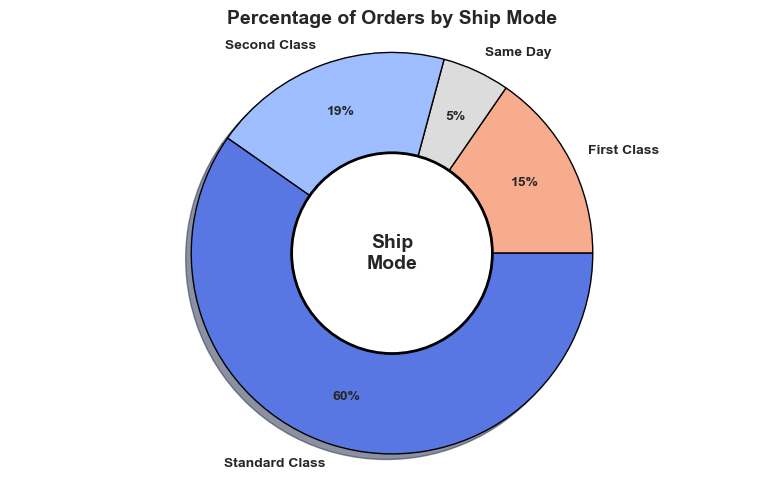


1. Order Distribution by Shipping Mode

Observation:
- Standard Class is the preferred shipping mode.
- Same Day shipping is rarely used.

Insight:
- Customers prefer economical shipping options.



In [10]:
# Analysis 6
# Count of Ship Mode

ship = data.groupby('Ship Mode')['Order ID'].count()

fig, ax = plt.subplots(1,1, figsize=(8,5))
colors = plt.cm.coolwarm(np.linspace(0.7, 0.1, len(ship)))

ax.set_title('Percentage of Orders by Ship Mode', fontsize=14, fontweight='bold')

plt.pie(ship,labels=ship.index,
    colors=colors,
    autopct='%1.f%%',
    pctdistance=0.75,
    shadow=True,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 1
    },
    textprops={
        'fontsize': 10,
        'fontweight': 'bold'
    }
)

# inner circle style
centre_circle = plt.Circle(
    (0, 0),
    0.50,
    fc='white', # Face Color - Inside (fill) color of the shape.
    ec='black', #Edge Color - It sets the border (outline) color of the shape.
    linewidth=2
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.text(
    0, 0,
    "Ship\nMode",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.axis('equal')

plt.savefig('../images/ship_mode.png', bbox_inches="tight")
fig.tight_layout()
plt.show()

print("""
1. Order Distribution by Shipping Mode

Observation:
- Standard Class is the most frequently used shipping mode.
- Same Day is the least preferred shipping mode.

Insight:
- Customers primarily choose standard shipping.
""")